# **RQ2**: Dynamic Community Detection

In [40]:
import os
import igraph as ig
import leidenalg

In [42]:
import json

for i in range(1, 11):
    print(f'\nAnalyzing graph of snapshot {i}')
    file = os.path.join('igraph_graphs', f'graph_snap{i}_p99.igp')
    g = ig.Graph.Read_Pickle(file)
    
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights='weight',
        resolution_parameter=1.0
    )
    print(f'\tCorrectly ran Leiden CD')
    
    print(f'\t#comms: {len(partition)}')

    communities = list()
    
    for j, com in enumerate(partition):
        print(f'\t\t{len(com)}')
        communities.append(list())
        for node in com:
            communities[j].append(g.vs[node]['token'])

    out = os.path.join('leiden_clusterings', f'clust_snap{i}.json')
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(communities, f)


Analyzing graph of snapshot 1
	Correctly ran Leiden CD
	#comms: 8
		15126
		8890
		8677
		6302
		6000
		2763
		1238
		464

Analyzing graph of snapshot 2
	Correctly ran Leiden CD
	#comms: 7
		16962
		9443
		7095
		6169
		3745
		3488
		287

Analyzing graph of snapshot 3
	Correctly ran Leiden CD
	#comms: 8
		21283
		12815
		10406
		7776
		6957
		3183
		1112
		655

Analyzing graph of snapshot 4
	Correctly ran Leiden CD
	#comms: 7
		15904
		11050
		10797
		8925
		8778
		8619
		558

Analyzing graph of snapshot 5
	Correctly ran Leiden CD
	#comms: 11
		19917
		12136
		11197
		10329
		9517
		7427
		2596
		1202
		600
		565
		2

Analyzing graph of snapshot 6
	Correctly ran Leiden CD
	#comms: 10
		17443
		13746
		13676
		12303
		7685
		6115
		4572
		2789
		2439
		2058

Analyzing graph of snapshot 7
	Correctly ran Leiden CD
	#comms: 9
		11577
		11323
		9842
		9178
		8354
		7411
		2472
		2175
		1855

Analyzing graph of snapshot 8
	Correctly ran Leiden CD
	#comms: 7
		19577
		13054
		9852
		7023
		3

In [ ]:
import json

for i in range(1, 11):
    print(f'\nAnalyzing graph of snapshot {i}')
    file = os.path.join('igraph_graphs', f'graph_snap{i}_p99.igp')
    g = ig.Graph.Read_Pickle(file)
    
    partition = g.community_infomap(
        edge_weights='weight'
    )

    print(f'\tCorrectly ran Infomap CD')
    
    print(f'\t#comms: {len(partition)}')

    communities = list()
    
    for j, com in enumerate(partition):
        # print(f'\t\t{len(com)}')
        communities.append(list())
        for node in com:
            communities[j].append(g.vs[node]['token'])

    out = os.path.join('infomap_clusterings', f'clust_snap{i}.json')
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(communities, f)


Analyzing graph of snapshot 1
	Correctly ran Infomap CD
	#comms: 87

Analyzing graph of snapshot 2
	Correctly ran Infomap CD
	#comms: 79

Analyzing graph of snapshot 3
	Correctly ran Infomap CD
	#comms: 114

Analyzing graph of snapshot 4
	Correctly ran Infomap CD
	#comms: 107

Analyzing graph of snapshot 5
	Correctly ran Infomap CD
	#comms: 79

Analyzing graph of snapshot 6
	Correctly ran Infomap CD
	#comms: 68

Analyzing graph of snapshot 7
	Correctly ran Infomap CD
	#comms: 76

Analyzing graph of snapshot 8
	Correctly ran Infomap CD
	#comms: 83

Analyzing graph of snapshot 9
	Correctly ran Infomap CD
	#comms: 64

Analyzing graph of snapshot 10
	Correctly ran Infomap CD
	#comms: 107


## Leiden communities comparison by snapshots

In [125]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import numpy as np

In [126]:
# def overlap_coeff(com1: list, com2: list) -> float:
#     """
#     Calculate Overlap Coefficient between two communities.
        
#     ---
    
#     Args:
#         com1 (list): First community
#         com2 (list): Second community
    
#     Returns:
#         float: Float representing the Overlap Coefficient
#     """
#     set1, set2 = set(com1), set(com2)
#     return len(set1 & set2) / min(len(set1), len(set2))


def directional_overlap(com_prev: list, com_next: list) -> float:
    """
    Directional overlap from previous snapshot to next snapshot.
    Penalizes small → large, rewards large → small.
    """
    set_prev, set_next = set(com_prev), set(com_next)
    inter = len(set_prev & set_next)

    if inter == 0:
        return 0.0

    return inter / len(set_next)


# def dice_coeff(com1: list, com2: list) -> float:
#     """
#     Calculate Overlap Coefficient between two communities.
        
#     ---
    
#     Args:
#         com1 (list): First community
#         com2 (list): Second community
    
#     Returns:
#         float: Float representing the Overlap Coefficient
#     """
#     set1, set2 = set(com1), set(com2)
#     return len(set1 & set2) / max(len(set1), len(set2))


def compare_partitions(part_prev: list, part_cur: str) -> list:
    """
    Compare two partitions (lists of communities) from consecutive snapshots by computing
    the Jaccard similarity between each pair of communities.

    Args:
        snap_prev (str): Path to the JSON file containing the previous snapshot's partition.
        snap_cur (str): Path to the JSON file containing the current snapshot's partition.

    Returns:
        list: A matrix (list of lists) where each element [i][j] is the Overlap Coefficient
              between the i-th community in the current snapshot and the j-th community in the previous snapshot.
    """
    sim_matrix = np.zeros((len(part_cur), len(part_prev)))
    for i, com_cur in enumerate(part_cur):
        for j, com_prev in enumerate(part_prev):
            sim = directional_overlap(com_prev, com_cur)
            sim_matrix[i][j] = sim
            
    return sim_matrix

In [127]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_temporal_community_similarity(sim_matrices,
                                       community_sizes,
                                       threshold=0.5,
                                       x_spacing=3.0,
                                       y_spacing=1.0,
                                       node_size=100,
                                       clustering='Leiden'):

    G = nx.DiGraph()

    # --- build graph ---
    for t, sim in enumerate(sim_matrices):
        n_curr, n_prev = sim.shape

        for i in range(n_prev):
            if community_sizes[t][i] > 50:
                G.add_node((t, i), snapshot=t, size=community_sizes[t][i])

        for j in range(n_curr):
            if community_sizes[t+1][j] > 50:
                G.add_node((t + 1, j), snapshot=t + 1, size=community_sizes[t + 1][j])

        for i in range(n_prev):
            for j in range(n_curr):
                w = sim[j, i]
                if (w >= threshold and
                    community_sizes[t][i] > 50 and
                    community_sizes[t + 1][j] > 50):
                    G.add_edge((t, i), (t + 1, j), weight=w, label=f"{w:.2f}")
                    

    # --- layered layout (robust) ---
    pos = {}
    layers = {}

    for n in G.nodes():
        snapshot = G.nodes[n].get("snapshot", None)
        if snapshot is None:
            raise ValueError(f"Node {n} has no snapshot attribute")
        layers.setdefault(snapshot, []).append(n)

    for t in sorted(layers):
        for idx, n in enumerate(sorted(layers[t])):
            pos[n] = (t * x_spacing, -idx * y_spacing)

    # --- plotting ---
    # plt.figure(figsize=(12, 8))
    _, ax = plt.subplots(figsize=(14, 8))
    
    node_colors = []

    curr_snap = None

    for n in G.nodes():
        if curr_snap != n[0]:
            if curr_snap is not None:
                print(f'\tTotal internal: {tot_internal}')
                print(f'\tTotal sources: {tot_sources}')
                print(f'\tTotal sinks: {tot_sinks}')
                print(f'\tTotal isolated: {tot_isolated}')
            tot_sources = tot_sinks = tot_isolated = tot_internal = 0
            curr_snap = n[0]
            print(f'\nSnapshot {curr_snap}:')
        
        indeg = G.in_degree(n)
        outdeg = G.out_degree(n)

        if n[0] == 0 and outdeg > 0:
            node_colors.append("black")
            tot_internal += 1
            continue
        if n[0] == 9 and indeg > 0:
            node_colors.append("black")
            tot_internal += 1
            continue

        if indeg == 0 and outdeg > 0:
            node_colors.append("green")   # no predecessors
            tot_sources += 1
        elif indeg > 0 and outdeg == 0:
            node_colors.append("red")     # no successors
            tot_sinks += 1
        elif indeg == 0 and outdeg == 0:
            node_colors.append('purple')  # no connections
            tot_isolated += 1
        else:
            node_colors.append("black")   # internal
            tot_internal += 1
            
    print(f'\tTotal internal: {tot_internal}')
    print(f'\tTotal sources: {tot_sources}')
    print(f'\tTotal sinks: {tot_sinks}')
    print(f'\tTotal isolated: {tot_isolated}')


    # draw nodes with constant size
    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_size,
        node_color=node_colors,
        alpha=0.8
    )

    # draw node cardinality above nodes
    node_labels = {
        n: str(G.nodes[n]["size"])
        for n in G.nodes()
    }

    # shift labels upward slightly
    label_pos = {
        n: (pos[n][0], pos[n][1] + 0.3)
        for n in pos
    }

    nx.draw_networkx_labels(
        G,
        label_pos,
        labels=node_labels,
        font_size=8
    )

    weights = [G[u][v]["weight"] for u, v in G.edges()]

    norm = mcolors.Normalize(vmin=min(weights), vmax=max(weights))
    cmap = cm.plasma  # perceptually uniform
    
    nx.draw_networkx_edges(
        G, pos,
        edge_color=weights,
        edge_cmap=cmap,
        edge_vmin=norm.vmin,
        edge_vmax=norm.vmax,
        alpha=0.6
    )
    
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    plt.colorbar(sm, ax=ax, label="Community directional overlap")

    plt.title(f'Evolution of {clustering}-detected communities',
              fontsize=20)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
            label='Source',
            markerfacecolor='green', markersize=10),

        Line2D([0], [0], marker='o', color='w',
            label='Sink',
            markerfacecolor='red', markersize=10),

        Line2D([0], [0], marker='o', color='w',
            label='Isolated',
            markerfacecolor='purple', markersize=10)
    ]

    plt.legend(
        handles=legend_elements,
        loc='lower right',
        frameon=False
    )


    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [128]:
sim_matrices = list()
community_sizes = list()

for i in range(1, 11):
    file = os.path.join('leiden_clusterings', f'clust_snap{i}.json')
    if i > 1:
        part_prev = part_cur
    with open(file, 'r', encoding='utf-8') as f:
        part_cur = json.load(f)
    
    community_sizes.append(list())
    
    for com in part_cur:
        community_sizes[-1].append(len(com))
    
    if i == 1:
        continue
    
    matrix = compare_partitions(part_prev=part_prev, part_cur=part_cur)
    sim_matrices.append(matrix)
    
    print(f'\nSnapshot {i} w.r.t. snapshot {i-1} (shape: {matrix.shape}):')
    for j, row in enumerate(matrix):
        print(f'\tCommunity {j}:')
        print(f'\t\tmax JS: {np.max(row)}')
        print(f'\t\tmax JS: {np.argmax(row)}')


Snapshot 2 w.r.t. snapshot 1 (shape: (7, 8)):
	Community 0:
		max JS: 0.65263530244075
		max JS: 0
	Community 1:
		max JS: 0.5775706872815842
		max JS: 1
	Community 2:
		max JS: 0.5162790697674419
		max JS: 4
	Community 3:
		max JS: 0.5851839844383206
		max JS: 3
	Community 4:
		max JS: 0.35594125500667556
		max JS: 2
	Community 5:
		max JS: 0.4724770642201835
		max JS: 5
	Community 6:
		max JS: 0.5365853658536586
		max JS: 0

Snapshot 3 w.r.t. snapshot 2 (shape: (8, 7)):
	Community 0:
		max JS: 0.6261335338063243
		max JS: 0
	Community 1:
		max JS: 0.49527896995708154
		max JS: 1
	Community 2:
		max JS: 0.4164904862579281
		max JS: 3
	Community 3:
		max JS: 0.5171039094650206
		max JS: 2
	Community 4:
		max JS: 0.3034353888170188
		max JS: 4
	Community 5:
		max JS: 0.5039271127866792
		max JS: 5
	Community 6:
		max JS: 0.4037769784172662
		max JS: 0
	Community 7:
		max JS: 0.5038167938931297
		max JS: 4

Snapshot 4 w.r.t. snapshot 3 (shape: (7, 8)):
	Community 0:
		max JS: 0.57771629


Snapshot 0:
	Total internal: 5
	Total sources: 0
	Total sinks: 0
	Total isolated: 3

Snapshot 1:
	Total internal: 5
	Total sources: 1
	Total sinks: 1
	Total isolated: 0

Snapshot 2:
	Total internal: 5
	Total sources: 0
	Total sinks: 2
	Total isolated: 1

Snapshot 3:
	Total internal: 7
	Total sources: 0
	Total sinks: 0
	Total isolated: 0

Snapshot 4:
	Total internal: 7
	Total sources: 0
	Total sinks: 2
	Total isolated: 1

Snapshot 5:
	Total internal: 7
	Total sources: 1
	Total sinks: 1
	Total isolated: 1

Snapshot 6:
	Total internal: 5
	Total sources: 0
	Total sinks: 4
	Total isolated: 0

Snapshot 7:
	Total internal: 5
	Total sources: 2
	Total sinks: 0
	Total isolated: 0

Snapshot 8:
	Total internal: 7
	Total sources: 0
	Total sinks: 1
	Total isolated: 0

Snapshot 9:
	Total internal: 8
	Total sources: 0
	Total sinks: 0
	Total isolated: 1


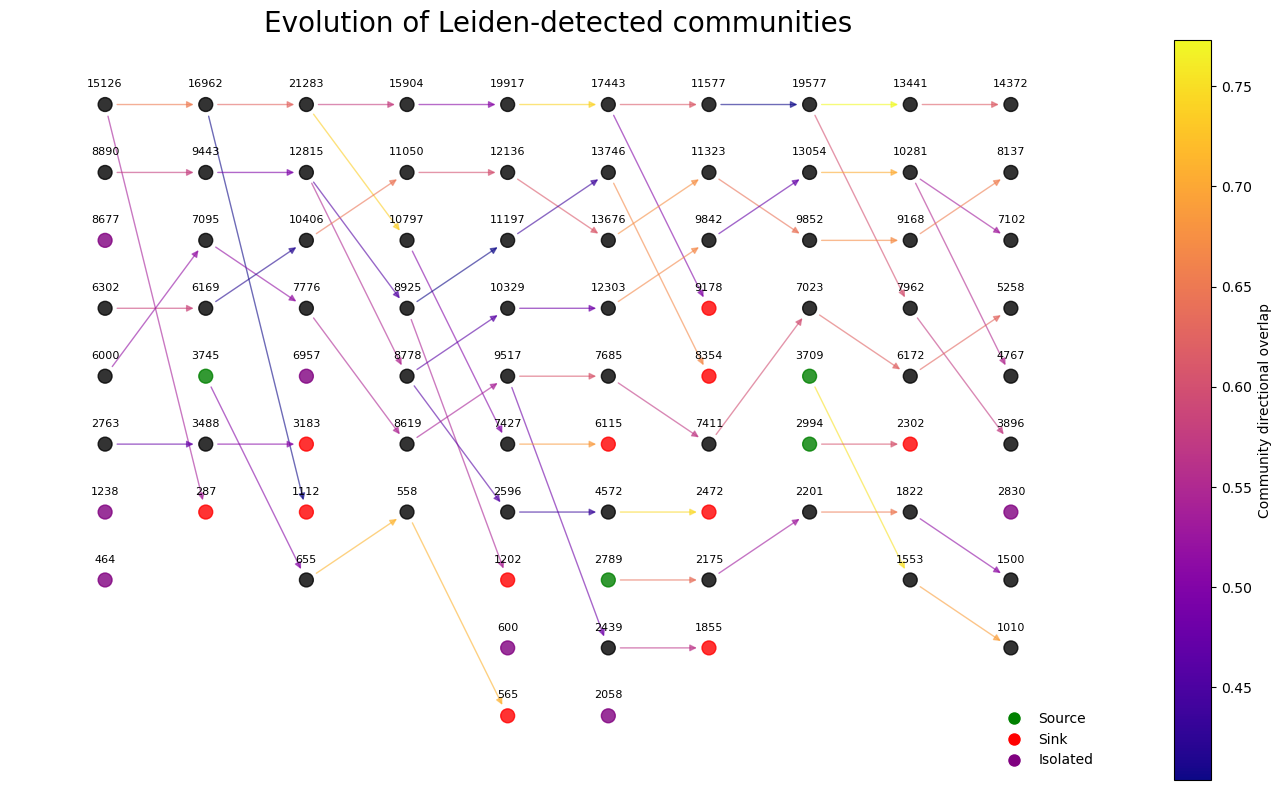

In [129]:
plot_temporal_community_similarity(sim_matrices, community_sizes, threshold=0.4)

## Infomap communities comparison by snapshot

In [130]:
sim_matrices = list()
community_sizes = list()

for i in range(1, 11):
    file = os.path.join('infomap_clusterings', f'clust_snap{i}.json')
    if i > 1:
        part_prev = part_cur
    with open(file, 'r', encoding='utf-8') as f:
        part_cur = json.load(f)
    
    community_sizes.append(list())
    
    for com in part_cur:
        community_sizes[-1].append(len(com))
    
    if i == 1:
        continue
    
    matrix = compare_partitions(part_prev=part_prev, part_cur=part_cur)
    sim_matrices.append(matrix)
    
    print(f'\nSnapshot {i} w.r.t. snapshot {i-1} (shape: {matrix.shape}):')
    for j, row in enumerate(matrix):
        print(f'\tCommunity {j}:')
        print(f'\t\tmax JS: {np.max(row)}')
        print(f'\t\tmax JS: {np.argmax(row)}')


Snapshot 2 w.r.t. snapshot 1 (shape: (79, 87)):
	Community 0:
		max JS: 0.5036231884057971
		max JS: 15
	Community 1:
		max JS: 0.3223965763195435
		max JS: 6
	Community 2:
		max JS: 0.5591397849462365
		max JS: 4
	Community 3:
		max JS: 0.7351598173515982
		max JS: 2
	Community 4:
		max JS: 0.6079274850207406
		max JS: 1
	Community 5:
		max JS: 0.4195064629847238
		max JS: 13
	Community 6:
		max JS: 0.7657142857142857
		max JS: 16
	Community 7:
		max JS: 0.6054177545691906
		max JS: 7
	Community 8:
		max JS: 0.4199706314243759
		max JS: 8
	Community 9:
		max JS: 0.5641461342395921
		max JS: 3
	Community 10:
		max JS: 0.2628520339740724
		max JS: 1
	Community 11:
		max JS: 0.23856858846918488
		max JS: 2
	Community 12:
		max JS: 0.5179856115107914
		max JS: 9
	Community 13:
		max JS: 0.3611111111111111
		max JS: 1
	Community 14:
		max JS: 0.6624737945492662
		max JS: 0
	Community 15:
		max JS: 0.46210333071072646
		max JS: 6
	Community 16:
		max JS: 0.655705996131528
		max JS: 17
	Com


Snapshot 0:
	Total internal: 25
	Total sources: 0
	Total sinks: 0
	Total isolated: 4

Snapshot 1:
	Total internal: 13
	Total sources: 1
	Total sinks: 17
	Total isolated: 5

Snapshot 2:
	Total internal: 12
	Total sources: 10
	Total sinks: 8
	Total isolated: 3

Snapshot 3:
	Total internal: 14
	Total sources: 1
	Total sinks: 12
	Total isolated: 5

Snapshot 4:
	Total internal: 13
	Total sources: 9
	Total sinks: 2
	Total isolated: 5

Snapshot 5:
	Total internal: 19
	Total sources: 1
	Total sinks: 7
	Total isolated: 3

Snapshot 6:
	Total internal: 18
	Total sources: 2
	Total sinks: 4
	Total isolated: 2

Snapshot 7:
	Total internal: 18
	Total sources: 0
	Total sinks: 7
	Total isolated: 3

Snapshot 8:
	Total internal: 13
	Total sources: 5
	Total sinks: 6
	Total isolated: 0

Snapshot 9:
	Total internal: 25
	Total sources: 0
	Total sinks: 0
	Total isolated: 8


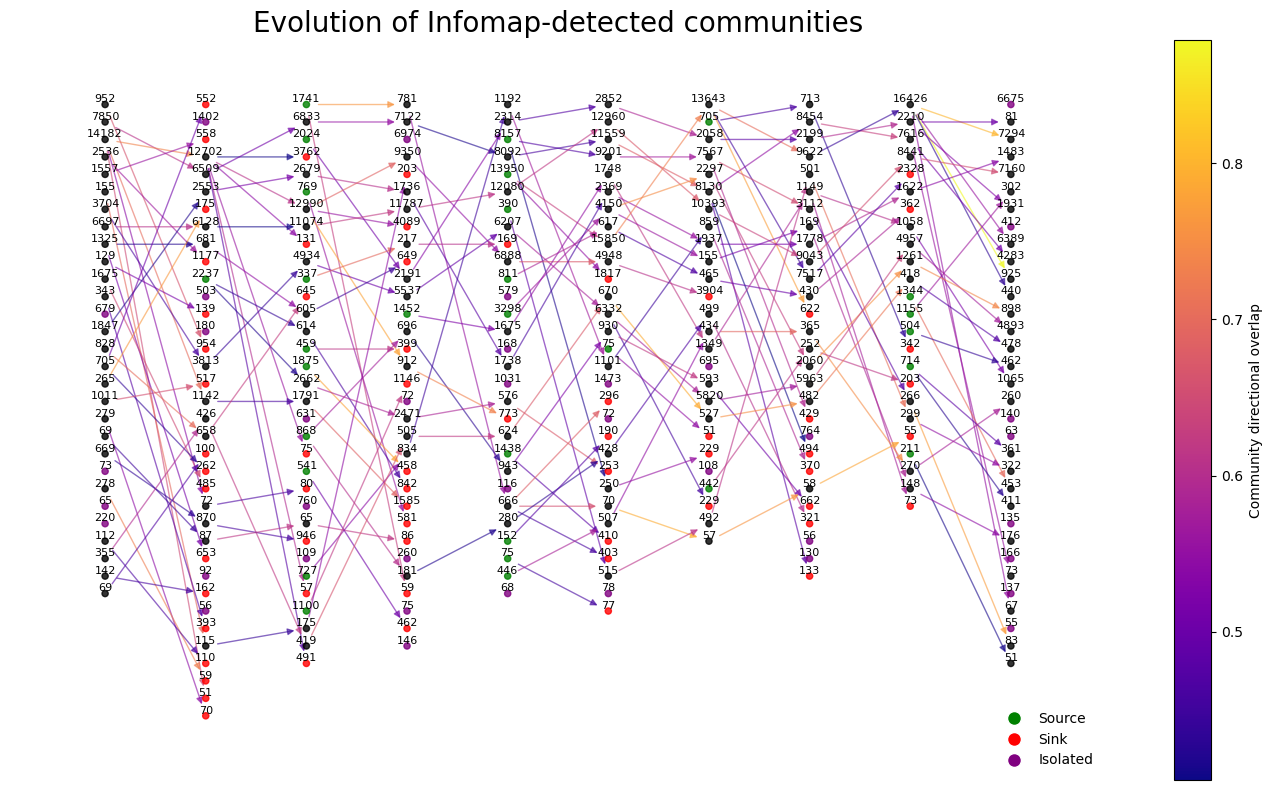

In [131]:
plot_temporal_community_similarity(sim_matrices, community_sizes, node_size=20, clustering='Infomap', threshold=0.4)